In [47]:
# 1) Imports y archivos
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

npz_path = Path("../data/processed/S01_EEG.npz")
meta_path = npz_path.with_suffix(".meta.json")

# 2) Cargar datos y labels
npz = np.load(npz_path)
datos = npz["data"]         # shape (n_trials, total_samples)
x = datos[:, :-3]           # señales
y = datos[:, -3:]           # etiquetas
n_trials, total_samples = x.shape
print("n_trials, total_samples:", n_trials, total_samples)
print("y shape:", y.shape)

n_trials, total_samples: 688 24576
y shape: (688, 3)


In [48]:
# 3) Extraer fs desde metadata (si existe), sino usar default 1024
if meta_path.exists():
    meta = json.load(open(meta_path, "r", encoding="utf8"))
    fs = meta.get("fs", None)
    print("fs desde meta:", fs)
else:
    meta = {}
    fs = None
    print("No existe meta. Usarás fs por defecto o lo definirás manualmente.")

if fs is None:
    fs = 1024   # tu valor conocido; o setear otro si corresponde
    print("Usando fs por defecto:", fs)

# 4) Número de canales y samples por canal
n_channels = 6
if total_samples % n_channels != 0:
    raise ValueError(f"Total samples ({total_samples}) no divisible por {n_channels}. Revisá datos.")
samples_per_channel = total_samples // n_channels
duration_sec = samples_per_channel / fs
print("samples_per_channel:", samples_per_channel, "→ duración (s):", duration_sec)
# esperamos 4096 y 4.0 s

fs desde meta: 1024
samples_per_channel: 4096 → duración (s): 4.0


In [49]:
# 5) Remoldear a (n_trials, n_channels, samples_per_channel)
x_channels = x.reshape(n_trials, n_channels, samples_per_channel)
print("x_channels shape:", x_channels.shape)  # (688, 6, 4096) esperado

x_channels shape: (688, 6, 4096)


Canales: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4']


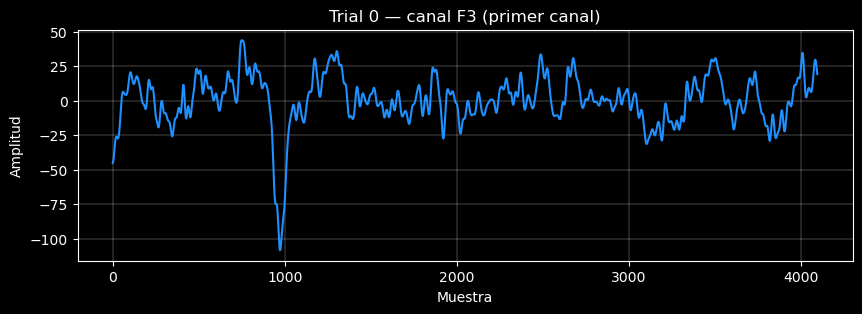

In [50]:
# 6) Mapear nombres de canales (según tu contexto)
channel_names = ["F3", "F4", "C3", "C4", "P3", "P4"]
print("Canales:", channel_names)

# Ver ejemplo rápido: plot del primer trial, canal F3
plt.style.use('dark_background')
plt.figure(figsize=(10,3))
plt.plot(x_channels[0, 0, :], color = 'dodgerblue')
plt.title("Trial 0 — canal F3 (primer canal)")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid(lw = 0.2)
plt.show()

In [53]:
# decodificar etiqueta
posible_modalidad = ['Imaginada', 'Pronunciada']
posible_estimulo = ['A', 'E', 'I', 'O', 'U', 'Arriba', 'Abajo', 'Adelante', 'Atras', 'Derecha', 'Izquierda']
posible_artefacto = ['Limpio', 'Parpadeo']

etiqueta = [posible_modalidad[int(y[0, 0]-1)], posible_estimulo[int(y[0, 1]-1)], posible_artefacto[int(y[0, 2]-1)]]
print(y[0])
print(etiqueta)

[1. 9. 2.]
['Imaginada', 'Atras', 'Parpadeo']


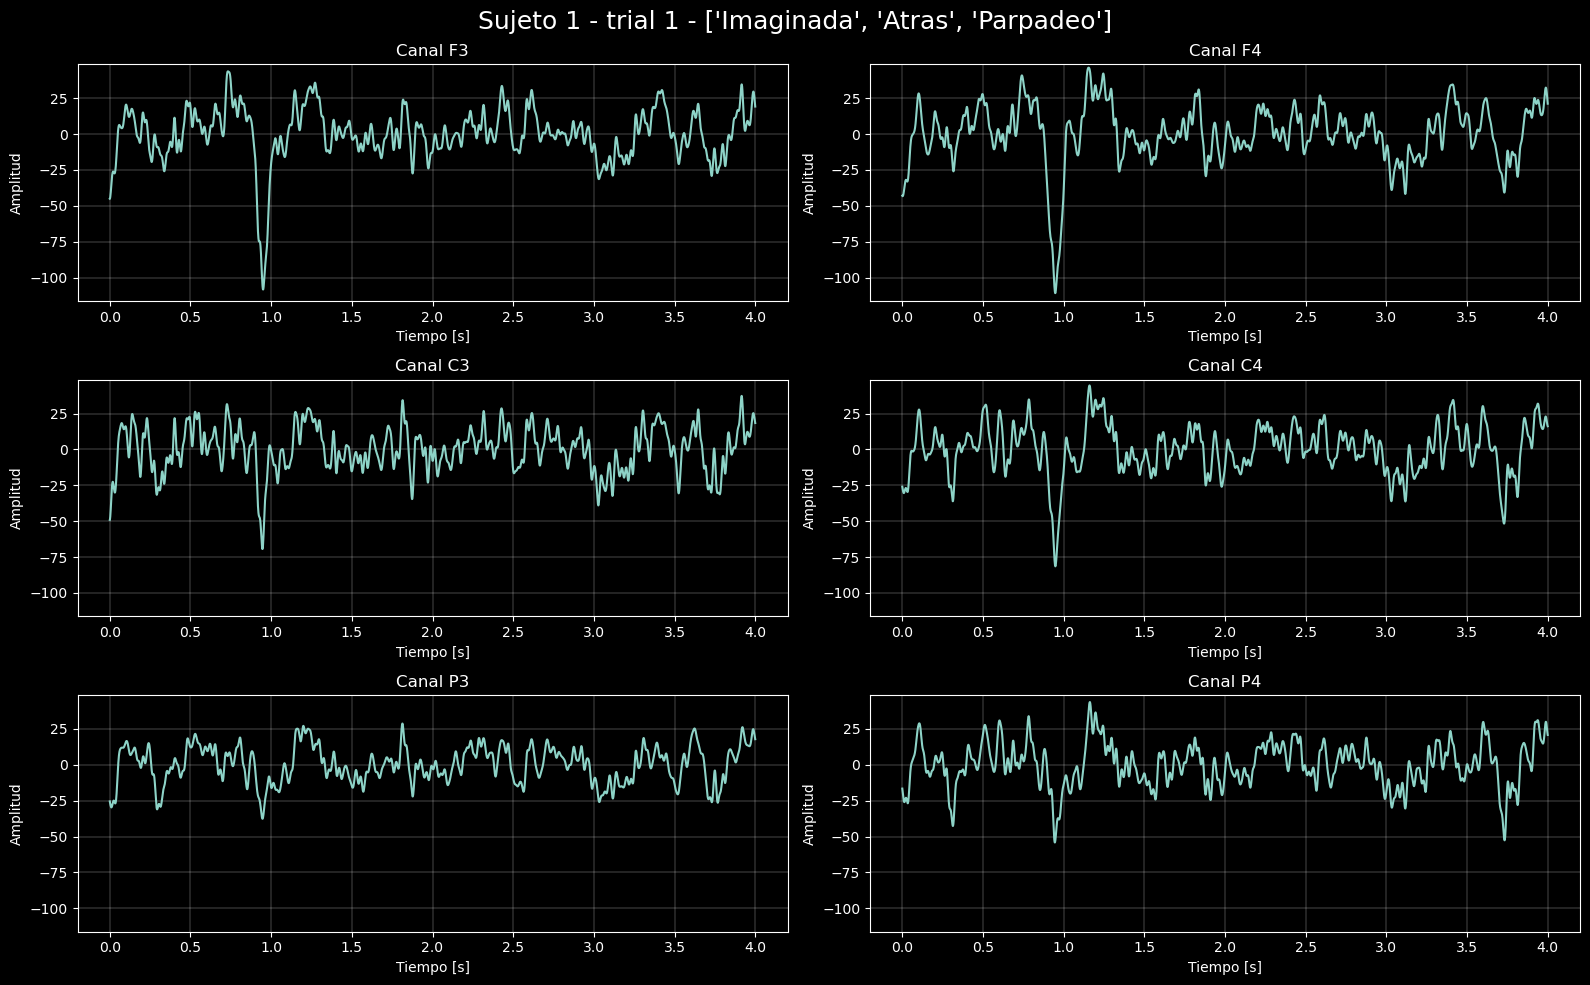

In [54]:
# grafico de cada canal contra el tiempo
tiempo = np.linspace(0, duration_sec, int(duration_sec*fs))
maximo = np.max(x_channels[0, :, :]) * 1.05
minimo = np.min(x_channels[0, :, :]) * 1.05

plt.figure(figsize = (16, 10))
plt.suptitle(f'Sujeto 1 - Trial 1 - {etiqueta}', fontsize = 18)
for i in range(len(x_channels[0, :, 0])):
    plt.subplot(3, 2, i+1)
    plt.plot(tiempo, x_channels[0, i, :])
    plt.title(f'Canal {channel_names[i]}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.ylim((minimo, maximo))
    plt.grid(lw = 0.2)
plt.tight_layout()
plt.show()